# 03_Preprocessing_FeatureEngineering

## Objective

This notebook prepares the VeReMi dataset for machine learning.

The preprocessing pipeline includes:

- Loading the sampled dataset
- Removing unnecessary features
- Verifying data types
- Engineering new features
- Selecting relevant predictors
- Preparing the final dataset for model training

The processed dataset generated here will serve as the direct input for XGBoost and Random Forest classifiers in the next notebook.

In [104]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Import Required Libraries

The required Python libraries for data manipulation, visualization, preprocessing and dataset preparation are imported.

In [105]:
PROJECT_ROOT = Path("..")

RAW_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
SAMPLE_PATH = PROJECT_ROOT / "data" / "samples"

OUTPUT_PATH = PROJECT_ROOT / "outputs"
FIGURE_PATH = OUTPUT_PATH / "figures"
REPORT_PATH = OUTPUT_PATH / "reports"
METRIC_PATH = OUTPUT_PATH / "metrics"
LOG_PATH = OUTPUT_PATH / "logs"

MODEL_PATH = PROJECT_ROOT / "models"

PREPROCESSING_PATH = MODEL_PATH / "preprocessing"
BASELINE_MODEL_PATH = MODEL_PATH / "baseline_models"
EXPLAINABILITY_PATH = MODEL_PATH / "explainability"

PREPROCESSING_PATH.mkdir(parents=True, exist_ok=True)
BASELINE_MODEL_PATH.mkdir(parents=True, exist_ok=True)
EXPLAINABILITY_PATH.mkdir(parents=True, exist_ok=True)

## Define Project Paths

Project directories are defined using pathlib to ensure platform-independent file management and reproducibility.

In [106]:
df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "samples" /
    "veremi_sample_100k.csv"
)

df.head()

,Unnamed: 0,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,...,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack,attack_type
0,0,3,27371.216284,981.098535,908.497891,3.826423,3.964059,-17.723786,-2.154895,-0.024182,...,-0.248402,-0.177659,0.000784,1.114785e-03,-0.971331,-0.237732,44.022409,33.840519,0,RandomSpeedOffset
1,1,3,52060.561117,1213.025174,984.277524,4.477449,4.459375,14.504808,2.605276,-0.008523,...,-0.653850,-0.117125,0.000001,1.847528e-07,0.992578,0.121610,2.560114,8.414909,0,DataReplay
2,2,3,28156.319142,140.514133,944.338854,2.965184,3.066191,-0.346027,4.671520,-0.000469,...,0.333247,-4.486889,0.000448,6.050771e-03,0.256103,0.966649,15.915074,9.636057,1,DoSDisruptive
3,3,3,28671.375689,558.005547,327.316562,4.934159,5.037039,11.792797,4.028876,0.022346,...,-0.030639,-0.010265,0.000066,2.237617e-05,0.954113,0.299446,2.854203,6.203941,1,RandomSpeedOffset
4,4,2,53612.000000,689.179631,547.143780,3.327547,3.374621,3.887137,-8.732709,0.000090,...,-1.829939,4.111129,0.000028,6.361425e-05,0.360402,-0.932797,5.648109,19.951521,0,DoS


## Dataset Shape

In [107]:
print(df.shape)

print(df.info())

(100000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   100000 non-null  int64  
 1   type         100000 non-null  int64  
 2   rcvTime      100000 non-null  float64
 3   pos_0        100000 non-null  float64
 4   pos_1        100000 non-null  float64
 5   pos_noise_0  100000 non-null  float64
 6   pos_noise_1  100000 non-null  float64
 7   spd_0        100000 non-null  float64
 8   spd_1        100000 non-null  float64
 9   spd_noise_0  100000 non-null  float64
 10  spd_noise_1  100000 non-null  float64
 11  acl_0        100000 non-null  float64
 12  acl_1        100000 non-null  float64
 13  acl_noise_0  100000 non-null  float64
 14  acl_noise_1  100000 non-null  float64
 15  hed_0        100000 non-null  float64
 16  hed_1        100000 non-null  float64
 17  hed_noise_0  100000 non-null  float64
 18  hed_noise_1  100000 non

## Load Sample Dataset

The cleaned 100,000-row sample created during Dataset Inspection is loaded. This representative subset is used throughout development before scaling the pipeline to the complete 22-million-row dataset.

In [108]:
df.columns

Index(['Unnamed: 0', 'type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0',
       'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0',
       'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0',
       'hed_noise_1', 'attack', 'attack_type'],
      dtype='str')

In [109]:
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,spd_noise_1,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack,attack_type
0,3,27371.216284,981.098535,908.497891,3.826423,3.964059,-17.723786,-2.154895,-0.024182,-0.017303,-0.248402,-0.177659,0.000784,1.114785e-03,-0.971331,-0.237732,44.022409,33.840519,0,RandomSpeedOffset
1,3,52060.561117,1213.025174,984.277524,4.477449,4.459375,14.504808,2.605276,-0.008523,-0.001531,-0.653850,-0.117125,0.000001,1.847528e-07,0.992578,0.121610,2.560114,8.414909,0,DataReplay
2,3,28156.319142,140.514133,944.338854,2.965184,3.066191,-0.346027,4.671520,-0.000469,0.006336,0.333247,-4.486889,0.000448,6.050771e-03,0.256103,0.966649,15.915074,9.636057,1,DoSDisruptive
3,3,28671.375689,558.005547,327.316562,4.934159,5.037039,11.792797,4.028876,0.022346,0.007632,-0.030639,-0.010265,0.000066,2.237617e-05,0.954113,0.299446,2.854203,6.203941,1,RandomSpeedOffset
4,2,53612.000000,689.179631,547.143780,3.327547,3.374621,3.887137,-8.732709,0.000090,-0.000203,-1.829939,4.111129,0.000028,6.361425e-05,0.360402,-0.932797,5.648109,19.951521,0,DoS


In [110]:
df.shape

(100000, 20)

## Remove Unnecessary Columns

The column "Unnamed: 0" represents the original row index from the CSV file. Since it contains no information related to vehicle behavior or attacks, it is removed prior to feature engineering.

## Feature Engineering

The original dataset stores position, speed, acceleration and heading as two-dimensional vector components (X and Y).

Instead of replacing these values, additional magnitude features are computed using Euclidean distance.

These engineered features preserve the original information while providing the model with more intuitive representations of vehicle motion.

In [111]:
# Position Magnitude

df["pos_magnitude"] = np.sqrt(
    df["pos_0"]**2 +
    df["pos_1"]**2
)

# Speed Magnitude

df["speed_magnitude"] = np.sqrt(
    df["spd_0"]**2 +
    df["spd_1"]**2
)

# Acceleration Magnitude

df["acceleration_magnitude"] = np.sqrt(
    df["acl_0"]**2 +
    df["acl_1"]**2
)

# Heading Magnitude

df["heading_magnitude"] = np.sqrt(
    df["hed_0"]**2 +
    df["hed_1"]**2
)

In [112]:
df.head()

,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,spd_noise_1,...,hed_0,hed_1,hed_noise_0,hed_noise_1,attack,attack_type,pos_magnitude,speed_magnitude,acceleration_magnitude,heading_magnitude
0,3,27371.216284,981.098535,908.497891,3.826423,3.964059,-17.723786,-2.154895,-0.024182,-0.017303,...,-0.971331,-0.237732,44.022409,33.840519,0,RandomSpeedOffset,1337.132287,17.854304,0.305396,1.0
1,3,52060.561117,1213.025174,984.277524,4.477449,4.459375,14.504808,2.605276,-0.008523,-0.001531,...,0.992578,0.121610,2.560114,8.414909,0,DataReplay,1562.124297,14.736924,0.664258,1.0
2,3,28156.319142,140.514133,944.338854,2.965184,3.066191,-0.346027,4.671520,-0.000469,0.006336,...,0.256103,0.966649,15.915074,9.636057,1,DoSDisruptive,954.735615,4.684318,4.499247,1.0
3,3,28671.375689,558.005547,327.316562,4.934159,5.037039,11.792797,4.028876,0.022346,0.007632,...,0.954113,0.299446,2.854203,6.203941,1,RandomSpeedOffset,646.920646,12.462019,0.032313,1.0
4,2,53612.000000,689.179631,547.143780,3.327547,3.374621,3.887137,-8.732709,0.000090,-0.000203,...,0.360402,-0.932797,5.648109,19.951521,0,DoS,879.962999,9.558768,4.500007,1.0


In [113]:
df.shape

(100000, 24)

In [114]:
df[[
    "pos_magnitude",
    "speed_magnitude",
    "acceleration_magnitude",
    "heading_magnitude"
]].describe()

,pos_magnitude,speed_magnitude,acceleration_magnitude,heading_magnitude
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,900.909454,10.729521,0.971167,0.981153
std,425.718379,8.535442,1.169021,0.116940
min,0.000000,0.000000,0.000000,0.000000
25%,552.182115,4.301454,0.103017,1.000000
50%,903.426700,12.094388,0.516923,1.000000
75%,1165.499643,13.934793,1.506003,1.000000
max,3010.086394,56.549294,4.512580,1.408897


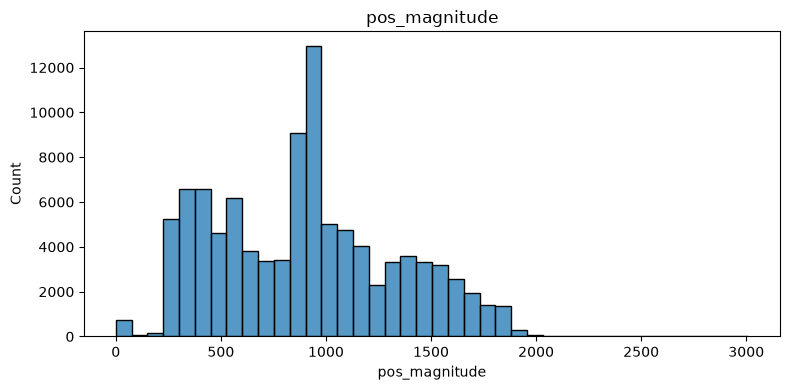

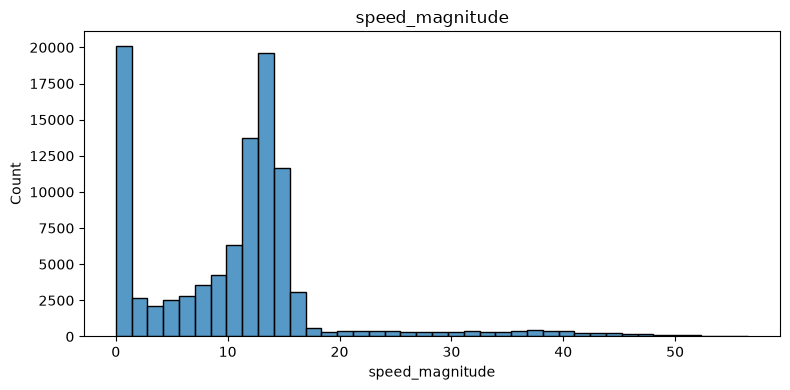

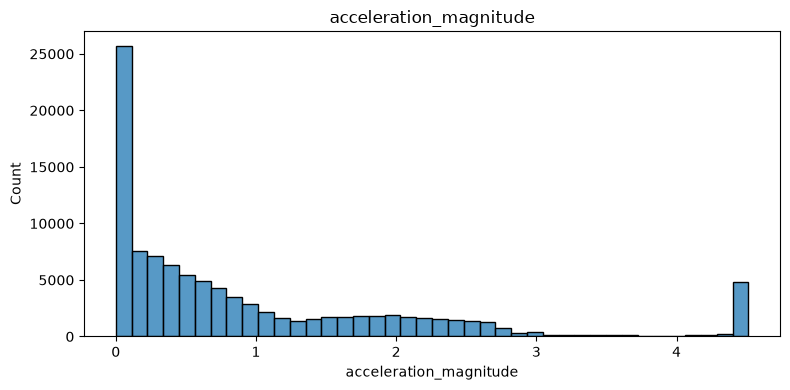

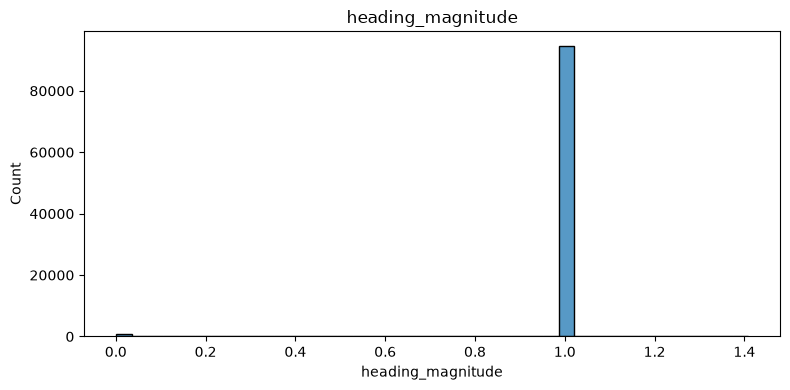

In [115]:
features = [
    "pos_magnitude",
    "speed_magnitude",
    "acceleration_magnitude",
    "heading_magnitude"
]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.histplot(df[feature], bins=40)

    plt.title(feature)

    plt.tight_layout()

    plt.savefig(
        FIGURE_PATH / f"{feature}_histogram.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Feature Quality Assessment

Before training the machine learning model, the engineered features are evaluated to identify features with extremely low variance.

Features with little or no variation contribute very little to prediction and can unnecessarily increase model complexity.

In [116]:
from sklearn.feature_selection import VarianceThreshold

# Remove target columns temporarily

feature_df = df.drop(columns=["attack", "attack_type"])

selector = VarianceThreshold(threshold=0)

selector.fit(feature_df)

variance = pd.DataFrame({
    "Feature": feature_df.columns,
    "Variance": selector.variances_
})

variance.sort_values("Variance", ascending=False)

,Feature,Variance
1,rcvTime,28977.000000
2,pos_0,4540.864741
3,pos_1,3883.972486
18,pos_magnitude,3010.086394
17,hed_noise_1,350.735886
16,hed_noise_0,338.053189
6,spd_0,65.746291
7,spd_1,64.845135
19,speed_magnitude,56.549294
4,pos_noise_0,28.086090


In [117]:
variance.sort_values("Variance", ascending=False).to_csv(
    REPORT_PATH / "feature_variance.csv",
    index=False
)

### Interpretation

The variance analysis shows that spatial and temporal features exhibit substantial variability, indicating that they carry significant information about vehicle behavior.

Some noise-related features have comparatively low variance; however, they are retained because tree-based machine learning models are capable of exploiting subtle variations that may still contribute to attack detection.

Therefore, no feature is removed solely based on variance analysis.

## Correlation of Engineered Features

The correlation among engineered magnitude features is examined to identify possible redundancy before model training.

In [118]:
engineered = [
    "pos_magnitude",
    "speed_magnitude",
    "acceleration_magnitude",
    "heading_magnitude"
]

corr = df[engineered].corr()

corr

,pos_magnitude,speed_magnitude,acceleration_magnitude,heading_magnitude
pos_magnitude,1.000000,0.178255,0.031083,0.068761
speed_magnitude,0.178255,1.000000,0.051407,-0.157146
acceleration_magnitude,0.031083,0.051407,1.000000,0.003915
heading_magnitude,0.068761,-0.157146,0.003915,1.000000


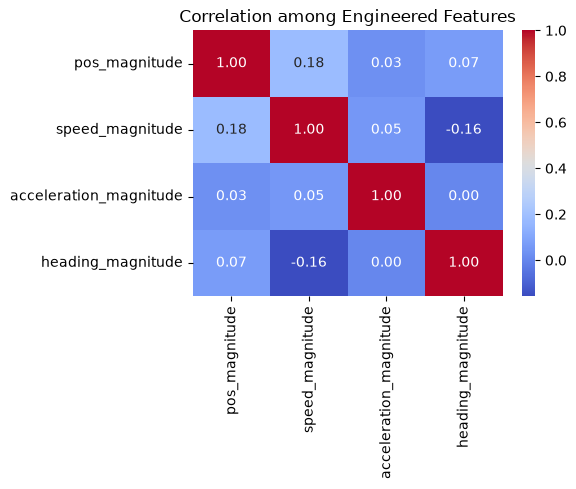

In [119]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation among Engineered Features")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "engineered_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The engineered magnitude features exhibit very low pairwise correlations.

The highest observed correlation is approximately 0.18, indicating that each engineered feature captures a distinct aspect of vehicle behavior.

Consequently, all engineered features are retained for subsequent model training.

## Baseline Feature Importance

A preliminary Random Forest classifier is trained on the complete sample dataset to estimate the relative importance of individual features.

This analysis serves only as an exploratory step to understand feature relevance before constructing the final machine learning models.

In [120]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data for importance estimation
X_temp = df.drop(columns=["attack", "attack_type"])
y_temp = df["attack"]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_temp, y_temp)

importance = pd.DataFrame({
    "Feature": X_temp.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,rcvTime,0.086097
5,pos_noise_1,0.054963
4,pos_noise_0,0.054747
2,pos_0,0.050947
16,hed_noise_0,0.049731
3,pos_1,0.049452
17,hed_noise_1,0.049260
18,pos_magnitude,0.048742
14,hed_0,0.048487
19,speed_magnitude,0.048255


In [121]:
importance.to_csv(
    REPORT_PATH / "baseline_feature_importance.csv",
    index=False
)

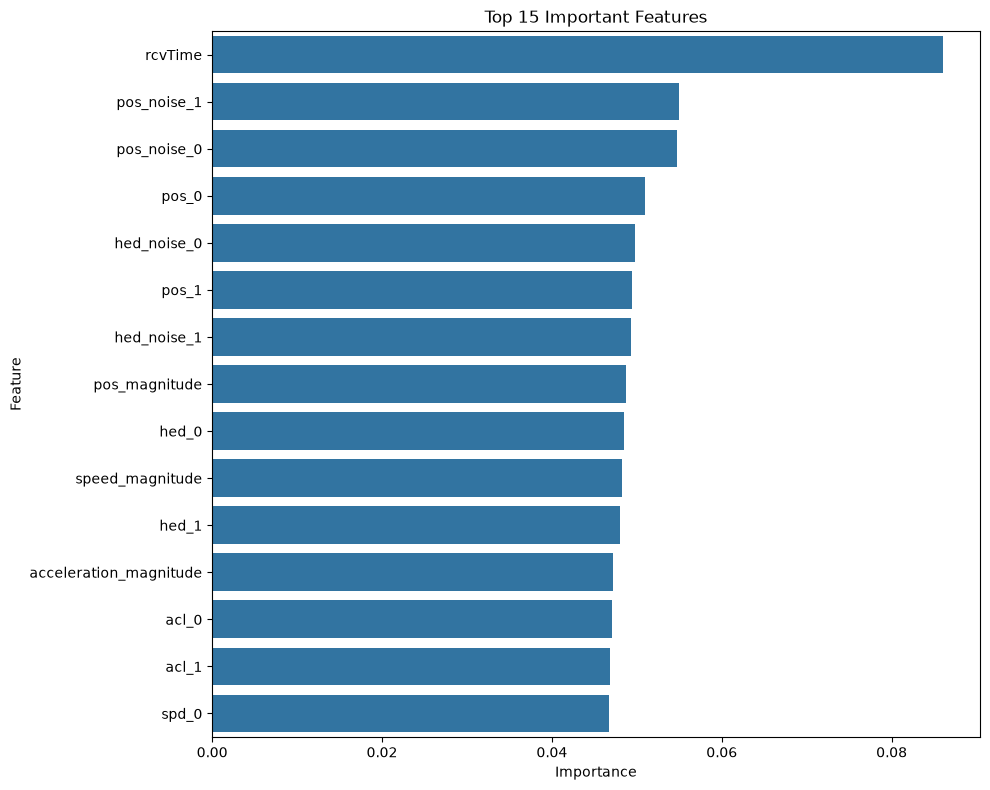

In [122]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "baseline_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The baseline Random Forest indicates that no individual feature dominates the prediction process.

Instead, predictive importance is distributed across temporal, positional, heading, speed, acceleration, and noise-related attributes.

The engineered magnitude features also appear among the most informative variables, demonstrating that the feature engineering process successfully extracted useful information from the original measurements.

Based on this analysis, all features are retained for the subsequent machine learning experiments.

# 8. Feature Scaling

Machine learning algorithms have different requirements regarding feature scales.

To ensure compatibility across multiple classifiers, numerical features are standardized using StandardScaler. The target variables are excluded from the scaling process.

In [123]:
from sklearn.preprocessing import StandardScaler

features = df.drop(columns=["attack", "attack_type"])

target_attack = df["attack"]
target_attack_type = df["attack_type"]

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns
)

X_scaled.head()

,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,spd_noise_1,...,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,pos_magnitude,speed_magnitude,acceleration_magnitude,heading_magnitude
0,0.398146,-0.905152,1.086005,0.778213,-0.036766,-0.010889,-2.020458,-0.404809,-2.085787,-1.363534,...,-0.005483,0.051021,-1.403689,-0.361074,1.657191,1.096467,1.024680,0.834733,-0.569515,0.161167
1,0.398146,1.080256,1.649241,1.016848,0.086077,0.082583,1.424579,0.081520,-0.735047,-0.120032,...,-0.325512,-0.384410,1.651763,0.120230,-0.597883,-0.261163,1.553182,0.469504,-0.262536,0.161167
2,0.398146,-0.842017,-0.955359,0.891079,-0.199275,-0.180327,-0.162883,0.292620,-0.040372,0.500207,...,-0.142683,1.979318,0.505955,1.252080,0.128474,-0.195958,0.126437,-0.708251,3.017994,0.161167
3,0.398146,-0.800599,0.058521,-1.051969,0.172255,0.191594,1.134681,0.226964,1.927665,0.602342,...,-0.299146,-0.375740,1.591919,0.358425,-0.581888,-0.379220,-0.596615,0.202978,-0.803116,0.161167
4,-2.511641,1.205016,0.377078,-0.359717,-0.130900,-0.122123,0.289616,-1.076839,0.007920,-0.015380,...,-0.314355,-0.359630,0.668223,-1.292047,-0.429932,0.354848,-0.049203,-0.137164,3.018644,0.161167


In [124]:
joblib.dump(
    scaler,
    PREPROCESSING_PATH / "standard_scaler.pkl"
)

['..\\models\\preprocessing\\standard_scaler.pkl']

# 9. Train-Test Split

Before model training, the processed dataset is divided into independent training and testing subsets.

A stratified split is performed using the binary attack label to preserve the original proportion of attack and normal messages in both subsets.

This ensures unbiased evaluation of machine learning models while maintaining class balance.

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    target_attack,
    test_size=0.20,
    random_state=42,
    stratify=target_attack
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (80000, 22)
Testing Features  : (20000, 22)
Training Labels   : (80000,)
Testing Labels    : (20000,)


# 10. Train-Test Split

The dataset was divided into training and testing subsets using an 80:20 ratio.

A stratified split was used to preserve the original class distribution of attack and normal messages in both subsets.

Maintaining identical class proportions prevents sampling bias and ensures reliable model evaluation.

In [126]:
print("Training Distribution")

print(
    y_train.value_counts(normalize=True)
)

print("\nTesting Distribution")

print(
    y_test.value_counts(normalize=True)
)

Training Distribution
attack
0    0.545288
1    0.454713
Name: proportion, dtype: float64

Testing Distribution
attack
0    0.5453
1    0.4547
Name: proportion, dtype: float64


### Observation

The attack distribution remained almost identical in both training and testing datasets.

This confirms that the stratified sampling procedure successfully preserved the original dataset distribution, preventing class imbalance during model training and evaluation.

# 11. Save Processed Dataset

The cleaned and engineered dataset is now exported for future modeling experiments.

Saving the processed dataset avoids repeating preprocessing steps in subsequent notebooks and ensures experiment reproducibility.

In [127]:
from pathlib import Path

processed_path = Path("../data/processed")

processed_path.mkdir(parents=True, exist_ok=True)

train_df = X_train.copy()
train_df["attack"] = y_train.values

test_df = X_test.copy()
test_df["attack"] = y_test.values

train_df.to_csv(
    processed_path / "train_processed.csv",
    index=False
)

test_df.to_csv(
    processed_path / "test_processed.csv",
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully


In [128]:
import os

os.listdir(processed_path)

['test_processed.csv', 'train_processed.csv']

In [129]:
%who

BASELINE_MODEL_PATH	 EXPLAINABILITY_PATH	 FIGURES	 FIGURE_PATH	 LOGS	 LOG_PATH	 METRICS	 METRIC_PATH	 MODEL_PATH	 
OUTPUT_PATH	 PREPROCESSING_PATH	 PROCESSED_DATA	 PROCESSED_PATH	 PROJECT_ROOT	 Path	 RAW_DATA	 RAW_PATH	 REPORTS	 
REPORT_PATH	 RandomForestClassifier	 SAMPLE_PATH	 StandardScaler	 VarianceThreshold	 X_scaled	 X_temp	 X_test	 X_train	 
corr	 df	 engineered	 feature	 feature_df	 feature_names	 features	 folder	 importance	 
joblib	 metadata	 np	 os	 pd	 plt	 processed_path	 rf	 scaler	 
selector	 sns	 target_attack	 target_attack_type	 target_column	 test_df	 train_df	 train_test_split	 variance	 
warnings	 y_temp	 y_test	 y_train	 


In [130]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    MODEL_PATH / "feature_names.pkl"
)

print("Feature List Saved")

Feature List Saved


In [131]:
target_column = "attack"

joblib.dump(
    target_column,
    MODEL_PATH / "target_column.pkl"
)

print("Target column saved.")

Target column saved.


In [132]:
metadata = {
    "rows": len(df),
    "features": len(feature_names),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "target": target_column
}

joblib.dump(
    metadata,
    MODEL_PATH / "dataset_metadata.pkl"
)

metadata

{'rows': 100000,
 'features': 22,
 'train_rows': 80000,
 'test_rows': 20000,
 'target': 'attack'}